In [ ]:
# =====================================
# LOAD MODEL READY DATA
# =====================================

import pandas as pd

df = pd.read_csv(r"C:\Users\dines\Downloads\Business_Analytics\airline_model_ready.csv")

print(df.shape)
df.head()

# =====================================
# LOYALTY MODEL DATA
# =====================================

X = df.drop(columns=["Loyalty_Program","Airline_Selected"])
y = df["Loyalty_Program"]
f
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

(2099, 36)
Train Shape: (1679, 34)
Test Shape: (420, 34)


In [3]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9452380952380952

Confusion Matrix
[[278   8]
 [ 15 119]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       286
         1.0       0.94      0.89      0.91       134

    accuracy                           0.95       420
   macro avg       0.94      0.93      0.94       420
weighted avg       0.95      0.95      0.94       420



In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [6]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9476190476190476

Confusion Matrix
[[277   9]
 [ 13 121]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       286
         1.0       0.93      0.90      0.92       134

    accuracy                           0.95       420
   macro avg       0.94      0.94      0.94       420
weighted avg       0.95      0.95      0.95       420



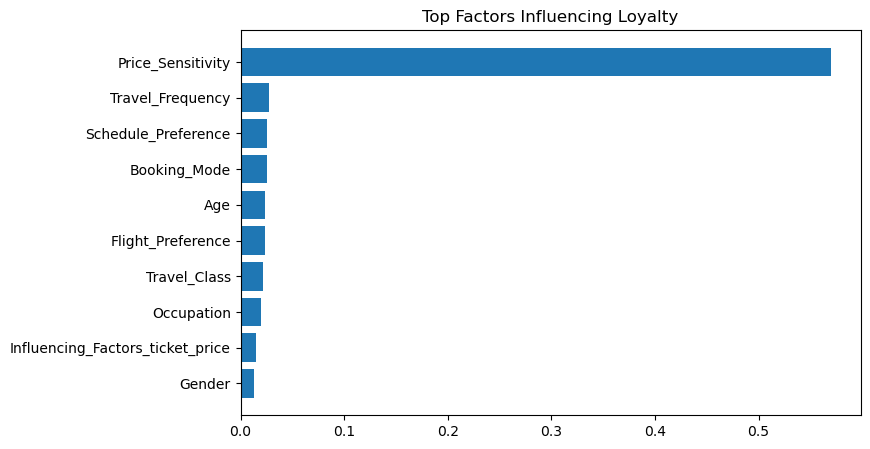

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

importance = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Factors Influencing Loyalty")
plt.show()

In [8]:
X2 = df.drop(columns=["Airline_Selected"])
y2 = df["Airline_Selected"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train2, y_train2)

y_pred_dt = dt_model.predict(X_test2)

In [10]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test2, y_pred_dt))

print(confusion_matrix(y_test2, y_pred_dt))
print(classification_report(y_test2, y_pred_dt))

Decision Tree Accuracy: 0.3142857142857143
[[ 7  0 14 18 10]
 [ 1  0  1  2  1]
 [20  1 62 54 32]
 [15  4 54 44 20]
 [ 5  0 19 17 19]]
              precision    recall  f1-score   support

           0       0.15      0.14      0.14        49
           1       0.00      0.00      0.00         5
           2       0.41      0.37      0.39       169
           3       0.33      0.32      0.32       137
           4       0.23      0.32      0.27        60

    accuracy                           0.31       420
   macro avg       0.22      0.23      0.22       420
weighted avg       0.32      0.31      0.32       420



In [11]:
rf_airline = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_airline.fit(X_train2, y_train2)

y_pred_rf_airline = rf_airline.predict(X_test2)

In [12]:
print("Random Forest Accuracy:",
      accuracy_score(y_test2, y_pred_rf_airline))

print(confusion_matrix(y_test2, y_pred_rf_airline))
print(classification_report(y_test2, y_pred_rf_airline))

Random Forest Accuracy: 0.3761904761904762
[[  0   0  32  17   0]
 [  0   0   4   1   0]
 [  0   0 118  48   3]
 [  0   0  95  37   5]
 [  1   0  42  14   3]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        49
           1       0.00      0.00      0.00         5
           2       0.41      0.70      0.51       169
           3       0.32      0.27      0.29       137
           4       0.27      0.05      0.08        60

    accuracy                           0.38       420
   macro avg       0.20      0.20      0.18       420
weighted avg       0.31      0.38      0.31       420



C:\Users\dines\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dines\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dines\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


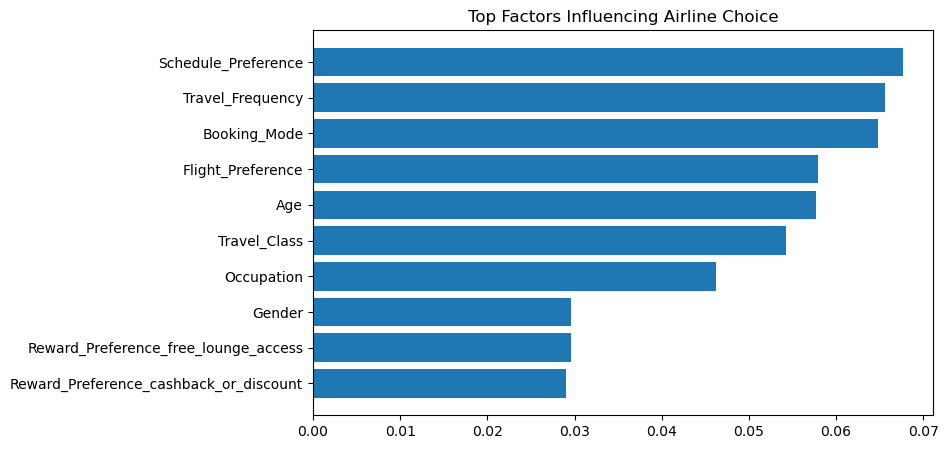

In [13]:
importance_airline = rf_airline.feature_importances_

feat_imp_airline = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": importance_airline
})

feat_imp_airline = feat_imp_airline.sort_values(
    by="Importance", ascending=False
).head(10)

plt.figure(figsize=(8,5))
plt.barh(feat_imp_airline["Feature"], feat_imp_airline["Importance"])
plt.gca().invert_yaxis()

plt.title("Top Factors Influencing Airline Choice")
plt.show()

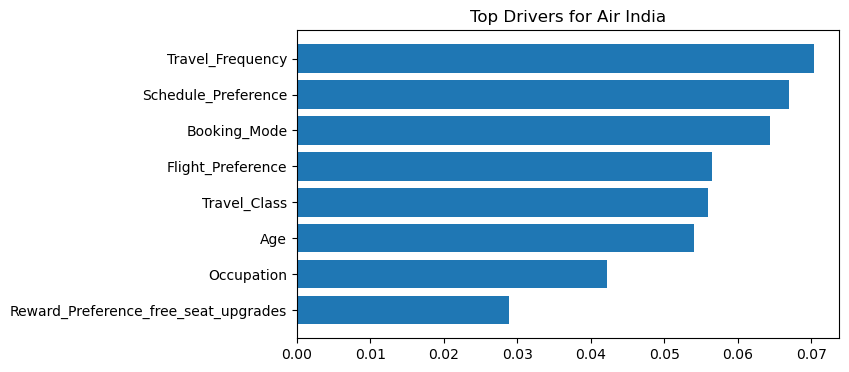

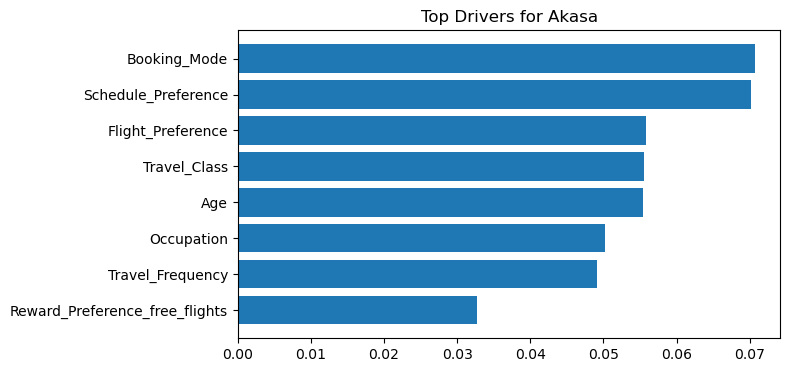

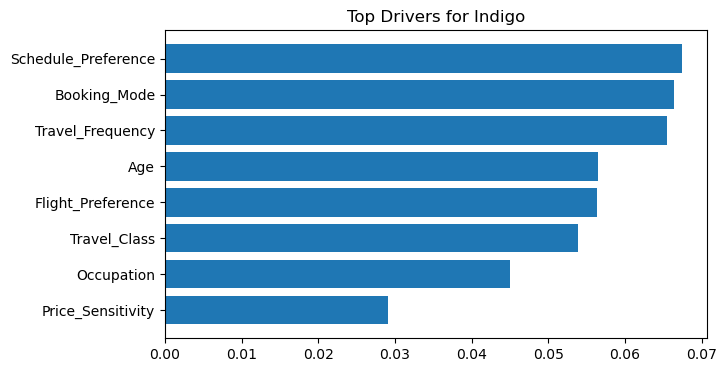

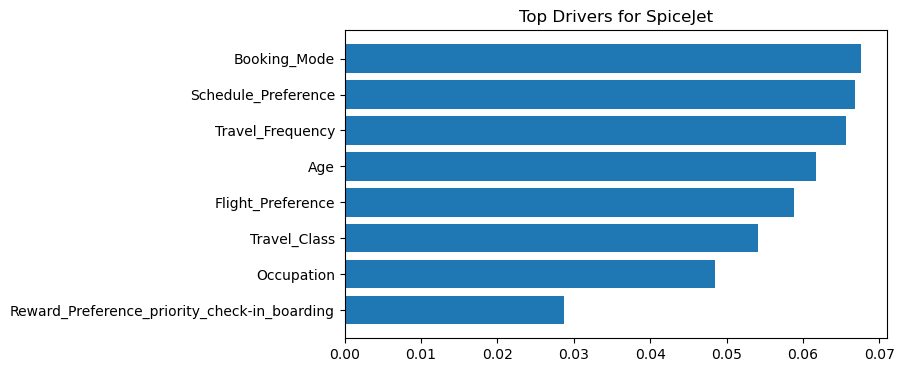

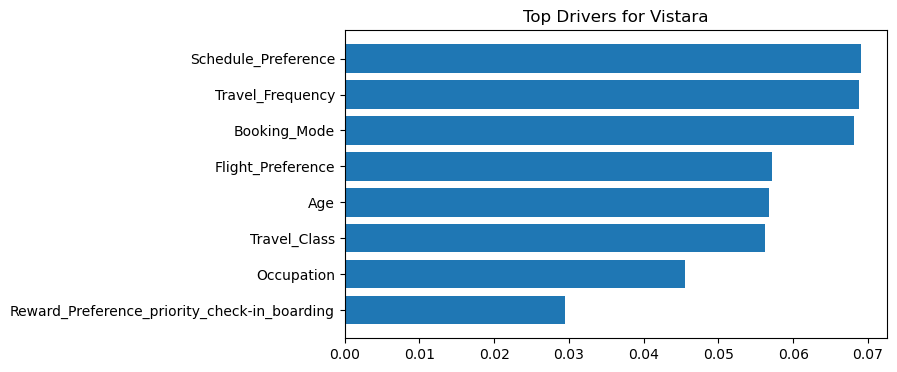

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

features = X2.columns

airline_mapping = {
0:"Air India",
1:"Akasa",
2:"Indigo",
3:"SpiceJet",
4:"Vistara"
}

for airline_id, airline_name in airline_mapping.items():

    # Create binary target (One vs Rest)
    y_binary = (y2 == airline_id).astype(int)

    # Train model
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    model.fit(X2, y_binary)

    # Get feature importance
    importance = model.feature_importances_

    df_imp = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    })

    df_imp = df_imp.sort_values(
        by="Importance",
        ascending=False
    ).head(8)

    # Plot
    plt.figure(figsize=(7,4))
    plt.barh(df_imp["Feature"], df_imp["Importance"])
    plt.gca().invert_yaxis()

    plt.title(f"Top Drivers for {airline_name}")
    plt.show()

In [15]:
"""
1️⃣ Indigo — Customer Drivers

From your chart, the strongest factors are:

Schedule Preference

Booking Mode

Travel Frequency

Age

Flight Preference

Travel Class

Occupation

Price Sensitivity

Insight

Indigo customers tend to be frequent travelers who prioritize convenience and scheduling. Booking behavior and price sensitivity also influence their decision.

Business Interpretation

Indigo appears to attract price-conscious frequent flyers who value punctual schedules and easy booking options.

2️⃣ SpiceJet — Customer Drivers

Top factors:

Booking Mode

Schedule Preference

Travel Frequency

Age

Flight Preference

Travel Class

Occupation

Priority Check-in / Boarding rewards

Insight

SpiceJet passengers respond strongly to booking convenience and reward incentives.

Business Interpretation

SpiceJet customers appear to be value-driven travelers attracted by incentives and flexible booking options.

3️⃣ Vistara — Customer Drivers

Top factors:

Schedule Preference

Travel Frequency

Booking Mode

Flight Preference

Age

Travel Class

Occupation

Priority Check-in rewards

Insight

Vistara customers prioritize schedule reliability and travel class preferences.

Business Interpretation

This suggests Vistara attracts premium or service-oriented passengers who value flight quality and convenience.

4️⃣ Air India — Customer Drivers

Top factors:

Travel Frequency

Schedule Preference

Booking Mode

Flight Preference

Travel Class

Age

Occupation

Free Seat Upgrades

Insight

Air India passengers show interest in loyalty rewards such as seat upgrades and are often frequent travelers.

Business Interpretation

Air India appears to appeal to loyalty-driven customers and frequent travelers seeking value-added benefits.

5️⃣ Akasa — Customer Drivers

Top factors:

Booking Mode

Schedule Preference

Flight Preference

Travel Class

Age

Occupation

Travel Frequency

Free Flights reward

Insight

Akasa passengers respond strongly to reward programs and booking behavior.

Business Interpretation

Akasa appears to attract reward-oriented travelers who value incentives such as free flights.

6️⃣ Key Overall Insight (Very Important for Report)

Across all airlines, the strongest predictors are:

Schedule Preference

Booking Mode

Travel Frequency

Flight Preference

Travel Class

Interpretation

This suggests that travel behavior factors are stronger predictors of airline choice than demographic characteristics like gender or occupation.
"""


'\n1️⃣ Indigo — Customer Drivers\n\nFrom your chart, the strongest factors are:\n\nSchedule Preference\n\nBooking Mode\n\nTravel Frequency\n\nAge\n\nFlight Preference\n\nTravel Class\n\nOccupation\n\nPrice Sensitivity\n\nInsight\n\nIndigo customers tend to be frequent travelers who prioritize convenience and scheduling. Booking behavior and price sensitivity also influence their decision.\n\nBusiness Interpretation\n\nIndigo appears to attract price-conscious frequent flyers who value punctual schedules and easy booking options.\n\n2️⃣ SpiceJet — Customer Drivers\n\nTop factors:\n\nBooking Mode\n\nSchedule Preference\n\nTravel Frequency\n\nAge\n\nFlight Preference\n\nTravel Class\n\nOccupation\n\nPriority Check-in / Boarding rewards\n\nInsight\n\nSpiceJet passengers respond strongly to booking convenience and reward incentives.\n\nBusiness Interpretation\n\nSpiceJet customers appear to be value-driven travelers attracted by incentives and flexible booking options.\n\n3️⃣ Vistara — Cust

In [16]:
import joblib

joblib.dump(rf_model, "loyalty_model.pkl")
joblib.dump(rf_airline, "airline_model.pkl")

print("Models saved successfully")

Models saved successfully
